In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pneumococcus_data import data_observation

['6B', '19F', '6A', '4', '14', '3', '19A']


In [2]:
Iran, Denmark, Brazil, Nepal, Mozambique = data_observation()

In [10]:
countries = [Denmark.strain, Iran.strain, Brazil.strain, Nepal.strain, Mozambique.strain]
common_strain = list(set.intersection(*map(set, countries)))
print(common_strain)

['6B', '19F', '6A', '4', '14', '3', '19A']


In [11]:
Denmark_common = []
Iran_common = []
Brazil_common = []
Nepal_common = []
Mozambique_common = []

for strain in common_strain:
    Denmark_common.append(1/(1- sum(Denmark[Denmark.strain == strain]['cases'])))
    Iran_common.append(1/(1 - sum(Iran[Iran.strain == strain]['cases'])))
    Brazil_common.append(1/(1- sum(Brazil[Brazil.strain == strain]['cases'])))
    Nepal_common.append(1/(1 - sum(Nepal[Nepal.strain == strain]['cases'])))
    Mozambique_common.append(1/(1 - sum(Mozambique[Mozambique.strain == strain]['cases'])))

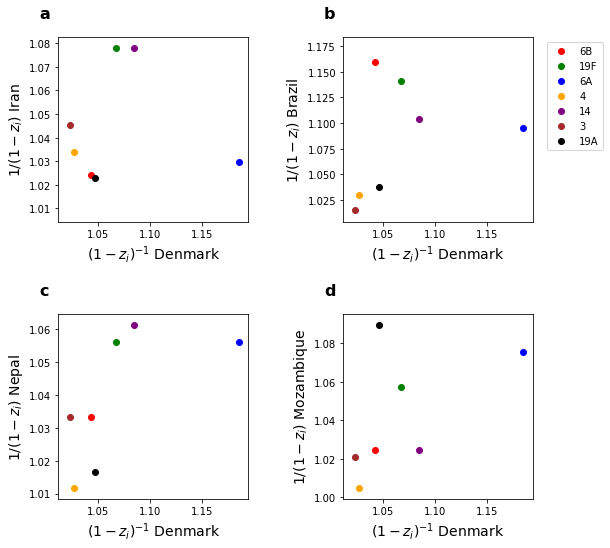

In [12]:
fig, ax = plt.subplots(2, 2, figsize = (8.5, 8.5))
fig.subplots_adjust(hspace = 0.5, wspace = 0.5)

country = np.array([[Iran_common, Brazil_common], [Nepal_common, Mozambique_common]])
label = np.array([['Iran', 'Brazil'], ['Nepal', 'Mozambique']])
color = np.array(['red', 'green', 'blue', 'orange', 'purple', 'brown', 'black'])
order = np.array([['a', 'b'], ['c', 'd']])

for i in range (0,2):
    for j in range (0,2):
        for k in range (0, len(common_strain)):
            ax[i,j].scatter(Denmark_common[k], country[i,j][k], color = color[k], label = '{}'.format(common_strain[k]))
        ax[i,j].set_xlabel('$(1 - z_i)^{-1}$ Denmark', fontsize = 14)
        ax[i,j].set_ylabel('$1/(1 - z_i)$ {}'.format(label[i,j]), fontsize = 14)
        ax[i,j].text(-.1, 1.1, '{}'.format(order[i,j]),  transform=ax[i,j].transAxes, size=16, weight='bold')
        
ax[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.rcParams["figure.dpi"] = 100
plt.show()

In [13]:
from scipy.stats import spearmanr #TEST CORRELATION
from scipy.stats import pearsonr

corr_DenIran, pDI = pearsonr(Denmark_common, Iran_common)
corr_DenBraz, pDB = pearsonr(Denmark_common, Brazil_common)
corr_DenNep, pDN = pearsonr(Denmark_common, Nepal_common)
corr_DenMoz, pDM = pearsonr(Denmark_common, Mozambique_common)

print(corr_DenIran, corr_DenBraz, corr_DenNep, corr_DenMoz)
print(pDI, pDB, pDN, pDM)

0.02339164765089132 0.3175055708277898 0.6502422563399156 0.5181099627429478
0.9602999689895153 0.4877388392236929 0.11382616590310003 0.23356540944043286
